# Import Libraries

In [1]:


import warnings
warnings.filterwarnings("ignore")  # ignore warnings because wants to keep notebook clean

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# sklearn for modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load datasets

In [2]:


# Load CSV files
customers = pd.read_csv("Data/customers.csv")
transactions = pd.read_csv("Data/transactions.csv")
app_usage = pd.read_csv("Data/app_usage.csv")
customer_service = pd.read_csv("Data/customer_service.csv")

# Quick check on dataset size
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("App Usage:", app_usage.shape)
print("Customer Service:", customer_service.shape)

# Preview data
customers.head()

Customers: (10005, 10)
Transactions: (775050, 8)
App Usage: (60030, 10)
Customer Service: (8516, 9)


,customer_id,age,state,account_age_days,tier,device_type,kyc_status,registration_date,is_churned,churn_date
0,CUST_000001,20.0,Terengganu,20,Basic,Android,Incomplete,2024-10-11,1,2024-10-24
1,CUST_000002,20.0,Kuala Lumpur,24,Basic,iOS,Verified,2024-10-07,0,NaN
2,CUST_000003,19.0,NaN,6,Basic,NaN,Verified,2024-10-25,0,NaN
3,CUST_000004,18.0,Johor,17,Basic,Android,Verified,2024-10-14,1,2024-10-03
4,CUST_000005,20.0,Kuala Lumpur,19,Basic,NaN,Verified,2024-10-12,1,2024-10-26


# Data Cleaning and formatting

In [3]:


# Standardize column names (lowercase, remove spaces)
customers.columns = customers.columns.str.strip().str.lower()
transactions.columns = transactions.columns.str.strip().str.lower()
app_usage.columns = app_usage.columns.str.strip().str.lower()
customer_service.columns = customer_service.columns.str.strip().str.lower()

# Convert date columns to datetime format
customers["registration_date"] = pd.to_datetime(customers["registration_date"], errors="coerce")
customers["churn_date"] = pd.to_datetime(customers["churn_date"], errors="coerce")
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"], errors="coerce")
app_usage["month"] = pd.to_datetime(app_usage["month"], errors="coerce")
customer_service["ticket_date"] = pd.to_datetime(customer_service["ticket_date"], errors="coerce")

# Remove extra spaces in categorical columns
for col in ["state", "tier", "device_type", "kyc_status"]:
    if col in customers.columns:
        customers[col] = customers[col].astype(str).str.strip()

# Check missing values

In [4]:


def missing_summary(df, name):
    summary = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values
    }).sort_values("missing_pct", ascending=False)
    
    print(f"\nMissing values summary: {name}")
    display(summary)

missing_summary(customers, "customers")
missing_summary(transactions, "transactions")
missing_summary(app_usage, "app_usage")
missing_summary(customer_service, "customer_service")


Missing values summary: customers


,column,missing_count,missing_pct
9,churn_date,7646,76.42
1,age,192,1.92
0,customer_id,0,0.00
2,state,0,0.00
3,account_age_days,0,0.00
4,tier,0,0.00
5,device_type,0,0.00
6,kyc_status,0,0.00
7,registration_date,0,0.00
8,is_churned,0,0.00



Missing values summary: transactions


,column,missing_count,missing_pct
3,amount,3789,0.49
0,transaction_id,0,0.00
1,customer_id,0,0.00
2,transaction_date,0,0.00
4,category,0,0.00
5,transaction_type,0,0.00
6,status,0,0.00
7,merchant_name,0,0.00



Missing values summary: app_usage


,column,missing_count,missing_pct
6,avg_session_duration_mins,3565,5.94
3,app_version,3030,5.05
2,logins_count,619,1.03
7,push_notifications_enabled,588,0.98
8,email_notifications_enabled,584,0.97
4,features_used_count,578,0.96
9,crash_count,542,0.90
5,features_list,384,0.64
0,customer_id,0,0.00
1,month,0,0.00



Missing values summary: customer_service


,column,missing_count,missing_pct
6,resolution_time_hours,391,4.59
7,satisfaction_score,391,4.59
0,ticket_id,0,0.00
1,customer_id,0,0.00
2,ticket_date,0,0.00
3,category,0,0.00
4,priority,0,0.00
5,channel,0,0.00
8,status,0,0.00


# Feature engineering - Transaction table

In [14]:


# Aggregate transaction data to customer level
txn_features = transactions.groupby("customer_id").agg(
    total_transactions=("transaction_id", "count"),
    total_amount=("amount", "sum"),
    avg_transaction_amount=("amount", "mean"),
    unique_merchants=("merchant_name", "nunique")
).reset_index()

# Count success and failed transactions
txn_status = transactions.pivot_table(
    index="customer_id",
    columns="status",
    values="transaction_id",
    aggfunc="count",
    fill_value=0
).reset_index()

txn_features = txn_features.merge(txn_status, on="customer_id", how="left")

# Count debit and credit transactions
txn_type = transactions.pivot_table(
    index="customer_id",
    columns="transaction_type",
    values="transaction_id",
    aggfunc="count",
    fill_value=0
).reset_index()

txn_features = txn_features.merge(txn_type, on="customer_id", how="left")

txn_features.head()

,customer_id,total_transactions,total_amount,avg_transaction_amount,unique_merchants,Failed,Success,Credit,Debit
0,CUST_000002,11,476.68,43.334545,11,0,11,2,9
1,CUST_000003,3,86.71,28.903333,3,0,3,0,3
2,CUST_000006,4,60.46,15.115000,4,0,4,0,4
3,CUST_000010,3,104.16,34.720000,3,0,3,0,3
4,CUST_000012,3,427.83,142.610000,3,0,3,0,3


# Feature engineering - App usage table

In [15]:


# Count number of features used from features_list
def count_features(x):
    if pd.isna(x):
        return 0
    return len(str(x).split(","))

app_usage["features_list_count"] = app_usage["features_list"].apply(count_features)

# Aggregate app usage to customer level
app_features = app_usage.groupby("customer_id").agg(
    avg_logins=("logins_count", "mean"),
    avg_session_duration=("avg_session_duration_mins", "mean"),
    avg_features_used=("features_used_count", "mean"),
    total_crashes=("crash_count", "sum"),
    push_enabled=("push_notifications_enabled", "max"),
    email_enabled=("email_notifications_enabled", "max")
).reset_index()

app_features.head()

,customer_id,avg_logins,avg_session_duration,avg_features_used,total_crashes,push_enabled,email_enabled
0,CUST_000001,12.916667,10.617000,4.916667,1.0,1.0,1.0
1,CUST_000002,23.666667,32.915455,4.333333,1.0,1.0,1.0
2,CUST_000003,2.272727,11.308333,1.833333,1.0,1.0,1.0
3,CUST_000004,12.250000,23.950909,5.833333,1.0,1.0,1.0
4,CUST_000005,1.416667,10.590000,1.454545,0.0,1.0,1.0


# Feature engineering - Customer Service table

In [16]:


service_features = customer_service.groupby("customer_id").agg(
    total_tickets=("ticket_id", "count"),
    avg_resolution_time=("resolution_time_hours", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    # last_ticket_date=("ticket_date", "max")
).reset_index()

# # Days since last support ticket
# service_features["days_since_last_ticket"] = (
#     reference_date - service_features["last_ticket_date"]
# ).dt.days

service_features.head()

,customer_id,total_tickets,avg_resolution_time,avg_satisfaction
0,CUST_000001,2,20.320000,2.500000
1,CUST_000002,5,25.480000,3.400000
2,CUST_000003,3,38.103333,4.333333
3,CUST_000004,4,20.812500,3.750000
4,CUST_000005,6,30.466667,2.166667


 # Merge all features into one dataset

In [17]:


df = customers.copy()

df = df.merge(txn_features, on="customer_id", how="left")
df = df.merge(app_features, on="customer_id", how="left")
df = df.merge(service_features, on="customer_id", how="left")

# Drop ID and raw date columns not needed for modeling
df = df.drop(columns=["customer_id", "registration_date", "churn_date"],
             errors="ignore")

df.head()

,age,state,account_age_days,tier,device_type,kyc_status,is_churned,total_transactions,total_amount,avg_transaction_amount,...,Debit,avg_logins,avg_session_duration,avg_features_used,total_crashes,push_enabled,email_enabled,total_tickets,avg_resolution_time,avg_satisfaction
0,20.0,Terengganu,20,Basic,Android,Incomplete,1,NaN,NaN,NaN,...,NaN,12.916667,10.617000,4.916667,1.0,1.0,1.0,2.0,20.320000,2.500000
1,20.0,Kuala Lumpur,24,Basic,iOS,Verified,0,11.0,476.68,43.334545,...,9.0,23.666667,32.915455,4.333333,1.0,1.0,1.0,5.0,25.480000,3.400000
2,19.0,nan,6,Basic,nan,Verified,0,3.0,86.71,28.903333,...,3.0,2.272727,11.308333,1.833333,1.0,1.0,1.0,3.0,38.103333,4.333333
3,18.0,Johor,17,Basic,Android,Verified,1,NaN,NaN,NaN,...,NaN,12.250000,23.950909,5.833333,1.0,1.0,1.0,4.0,20.812500,3.750000
4,20.0,Kuala Lumpur,19,Basic,nan,Verified,1,NaN,NaN,NaN,...,NaN,1.416667,10.590000,1.454545,0.0,1.0,1.0,6.0,30.466667,2.166667


# EDA

Churn rate: 23.58%


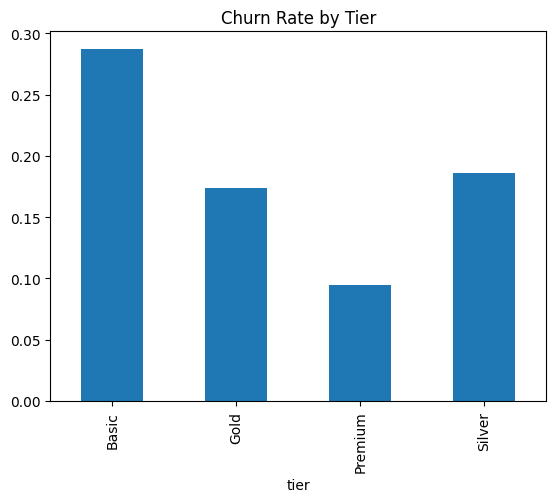

,total_transactions,total_amount,avg_logins,avg_session_duration,total_crashes,total_tickets,avg_satisfaction
is_churned,,,,,,,
0,91.111687,93033.579400,23.897222,29.093437,0.599137,1.263383,3.755222
1,46.973326,47685.974508,11.931659,15.145395,0.598983,2.297403,2.704245


In [18]:


# Overall churn rate
churn_rate = df["is_churned"].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

# Churn by tier
df.groupby("tier")["is_churned"].mean().plot(kind="bar", title="Churn Rate by Tier")
plt.show()

# Compare key metrics between churned and non-churned customers 
eda_cols = [ "total_transactions", "total_amount",
            "avg_logins", "avg_session_duration", "total_crashes", "total_tickets", "avg_satisfaction"]

df.groupby("is_churned")[eda_cols].mean()

The churn rate in the dataset is 23.58%. Basic customers show the highest churn rate, while Premium customers have the lowest.

When comparing churned and active customers, the churned group appears much less engaged overall. They make fewer transactions, spend less, log in less often, and spend less time in the app. They also tend to raise more support tickets and report lower satisfaction. These patterns suggest that both usage behavior and customer experience play an important role in churn.

# Modeling

In [19]:


target = "is_churned"

X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["number"]).columns

# Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Split train and testd
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In this case im trying to use 2 models for comparison, which are logistic regression and random forest which are technically okay for binary use cases

In [20]:
# Logistic Regression model
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

# Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'account_age_days', 'total_transactions', 'total_amount',
       'avg_transaction_amount', 'unique_merchants', 'Failed', 'Success',
       'Credit', 'Debit', 'avg_logins', 'avg_session_duration',
       'avg...
       'total_tickets', 'avg_resolution_time', 'avg_satisfaction'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['state', 'tier', 'device_type', 'kyc_status'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

# Both model evaluation 

In [21]:


def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{model_name}")
    print("Accuracy :", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall   :", recall_score(y_test, preds))
    print("F1 Score :", f1_score(y_test, preds))
    print("ROC AUC  :", roc_auc_score(y_test, probs))

evaluate_model(log_model, X_test, y_test, "Logistic Regression")
evaluate_model(rf_model, X_test, y_test, "Random Forest")


Logistic Regression
Accuracy : 0.9920039980009995
Precision: 0.975
Recall   : 0.9915254237288136
F1 Score : 0.9831932773109243
ROC AUC  : 0.999824023677822

Random Forest
Accuracy : 0.9955022488755623
Precision: 0.9936034115138592
Recall   : 0.9872881355932204
F1 Score : 0.9904357066950054
ROC AUC  : 0.9998018534325082


Random Forest is the best model to go for in this case


# CHURN PREDICTION ANALYSIS

The model performs very well, with ROC-AUC above 0.99. After removing some features that could lead to leakage, the performance is still very high.

This is probably because many of the features, like transaction activity and app usage, are directly linked to churn, since churn is defined by inactivity. Because of that, the model can easily tell the difference between churned and active users.

In a real situation, the results would likely be lower. To make the model more realistic, we should use a time-based approach where we train on past data and predict future churn.